In [1]:
#importação bibliotecas
import os
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt

from zipfile import ZipFile
from urllib.request import urlretrieve

from IPython.display import HTML
from matplotlib.animation import FuncAnimation

from IPython.display import YouTubeVideo, display, HTML
from base64 import b64encode

%matplotlib inline

In [2]:
def download_and_unzip(url, save_path):
    print(f"Downloading and extracting assests....", end="")

    urlretrieve(url, save_path)

    try:
        with ZipFile(save_path) as z:
            z.extractall(os.path.split(save_path)[0])

        print("Done")

    except Exception as e:
        print("\nInvalid file.", e)

URL = r"https://www.dropbox.com/s/ld535c8e0vueq6x/opencv_bootcamp_assets_NB11.zip?dl=1"

asset_zip_path = os.path.join(os.getcwd(), f"opencv_bootcamp_assets_NB11.zip")

if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path)   

In [2]:
video_input_file_name = "race_car.mp4"

#Função para desenhar o retangulo em cada pixel 
def drawRectangle(frame, bbox):
    p1 = (int(bbox[0]), int(bbox[1]))
    p2 = (int(bbox[0] + bbox[2]), int(bbox[1] + bbox[3]))
    cv2.rectangle(frame, p1, p2, (255, 0, 0), 2, 1)


#exibe o resultado
def displayRectangle(frame, bbox):
    plt.figure(figsize=(20, 10))
    frameCopy = frame.copy()
    drawRectangle(frameCopy, bbox)
    frameCopy = cv2.cvtColor(frameCopy, cv2.COLOR_RGB2BGR)
    plt.imshow(frameCopy)
    plt.axis("off")

#escreve na imagem
def drawText(frame, txt, location, color=(50, 170, 50)):
    cv2.putText(frame, txt, location, cv2.FONT_HERSHEY_SIMPLEX, 1, color, 3)

In [5]:
# Lista de trackers disponíveis
tracker_types = [
    "BOOSTING", "MIL", "KCF", "CSRT", 
    "TLD", "MEDIANFLOW", "GOTURN", "MOSSE"
]

#Bloco de ifelse que vai definir qual algoritmo vai ser utilizado
if tracker_type == "BOOSTING":
    tracker = cv2.legacy.TrackerBoosting_create()
elif tracker_type == "MIL":
    tracker = cv2.legacy.TrackerMIL_create()
elif tracker_type == "KCF":
    tracker = cv2.legacy.TrackerKCF_create()
elif tracker_type == "CSRT":
    tracker = cv2.legacy.TrackerCSRT_create()
elif tracker_type == "TLD":
    tracker = cv2.legacy.TrackerTLD_create()
elif tracker_type == "MEDIANFLOW":
    tracker = cv2.legacy.TrackerMedianFlow_create()
elif tracker_type == "GOTURN":
    tracker = cv2.TrackerGOTURN_create() 
else:
    tracker = cv2.legacy.TrackerMOSSE_create()

In [6]:
#le o video
video = cv2.VideoCapture(video_input_file_name)
ok, frame = video.read()

#printa caso não consiga abrir o vídeo
if not video.isOpened():
    print("Could not open video")
    sys.exit()
else:
    #pega a altura e a largura
    width = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))

#troca o nome do arquivo 
video_output_file_name = "race_car-" + tracker_type + ".mp4"
video_out = cv2.VideoWriter(video_output_file_name, cv2.VideoWriter_fourcc(*"XVID"), 10, (width, height))

video_output_file_name

OpenCV: FFMPEG: tag 0x44495658/'XVID' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


'race_car-KCF.mp4'

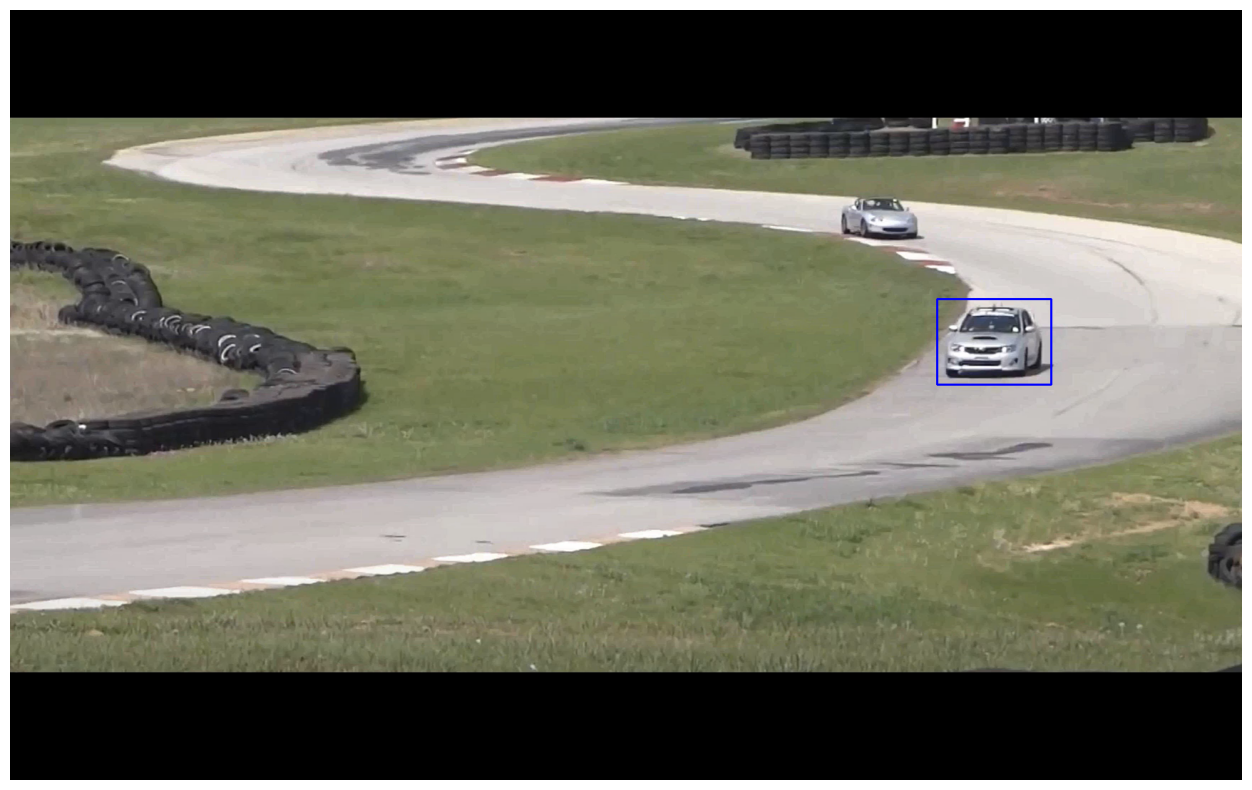

In [7]:
#define os pixels da caixa a ser desenhada
bbox = (1300, 405, 160, 120)

#mostra o primeiro frame com a caixa desenhada
displayRectangle(frame, bbox)

In [8]:
#Inicializa o tracker com o primeiro frame e onde fica a caixa

ok = tracker.init(frame, bbox)

In [9]:
#loop para desenhar os quadrados ao longo dos frames
while True:
    ok, frame = video.read()

    if not ok:
        break

    #começa a contar 
    timer = cv2.getTickCount()

    #atializa o tracker
    ok, bbox = tracker.update(frame)

    #calcula os frames por segundo de acordo com o timer
    fps = cv2.getTickFrequency() / (cv2.getTickCount() - timer)

    #desenha as caixas
    if ok:
        drawRectangle(frame, bbox)
    else:
        drawText(frame, "Tracking failure detected", (80, 140), (0, 0, 255))

    #escreve no vídeo as informações
    drawText(frame, tracker_type + " Tracker", (80, 60))
    drawText(frame, "FPS : " + str(int(fps)), (80, 100))

    video_out.write(frame)

video.release()
video_out.release()

In [12]:
#muda o vídeo de formato 
!ffmpeg -y -i {video_output_file_name} -c:v libx264 $"race_car_track_x264.mp4"  -hide_banner -loglevel error

In [14]:
#demonstração do tracker KCF
mp4 = open("race_car_track_x264.mp4", "rb").read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""<video width=1024 controls><source src="{data_url}" type="video/mp4"></video>""")

In [ ]:
#Tracker KCF
HTML('<iframe width="560" height="315" src="https://www.youtube.com/embed/pk3tmdRX4ww" frameborder="0" allowfullscreen></iframe>')

In [2]:
#Tracker: CSRT
HTML('<iframe width="560" height="315" src="https://www.youtube.com/embed/6gGDf-7ypBE" frameborder="0" allowfullscreen></iframe>')

In [4]:
#Tracker: GOTURN
HTML('<iframe width="560" height="315" src="https://www.youtube.com/embed/0bnWxc4zMvY" frameborder="0" allowfullscreen></iframe>')